In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams['figure.dpi'] = 100

In [2]:
              
df = pd.read_csv('titanic.csv')

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (891, 12)


Columns with missing values:
          Missing Count  Percentage (%)
Cabin               687       77.104377
Age                 177       19.865320
Embarked              2        0.224467


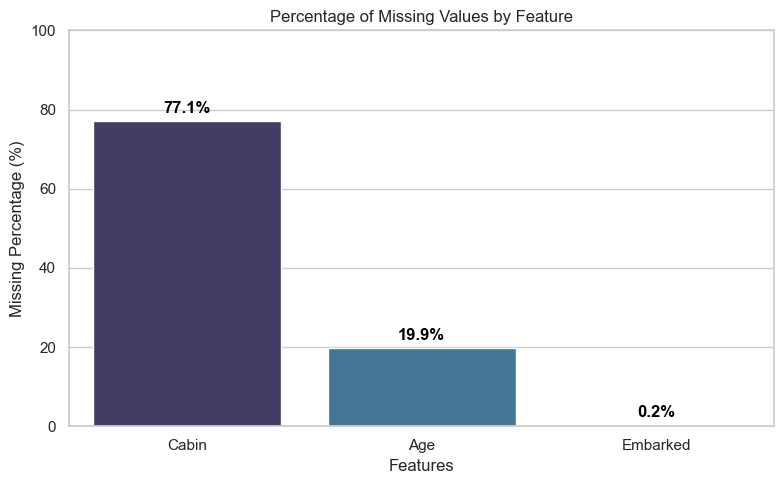

In [3]:
                           
missing_counts = df.isnull().sum()

missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_pct})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("Columns with missing values:")

print(missing_df)

if not missing_df.empty:

    plt.figure(figsize=(8, 5))

    sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='mako')

    plt.title('Percentage of Missing Values by Feature')

    plt.ylabel('Missing Percentage (%)')

    plt.xlabel('Features')

    plt.ylim(0, 100)

    for idx, row in enumerate(missing_df.itertuples()):

        plt.text(idx, row[2] + 2, f"{row[2]:.1f}%", color='black', ha="center", fontweight='bold')

    plt.tight_layout()

    plt.show()

else:

    print("No missing values found.")

Target variable 'Survived' distribution:
          Count  Percentage (%)
Survived                       
0           549       61.616162
1           342       38.383838


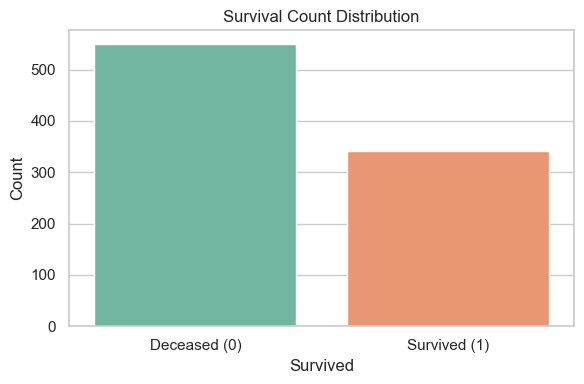

In [4]:
                             
survived_counts = df['Survived'].value_counts()

survived_pct = df['Survived'].value_counts(normalize=True) * 100

print("Target variable 'Survived' distribution:")

print(pd.DataFrame({'Count': survived_counts, 'Percentage (%)': survived_pct}))

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Survived', palette='Set2')

plt.title('Survival Count Distribution')

plt.xticks([0, 1], ['Deceased (0)', 'Survived (1)'])

plt.ylabel('Count')

plt.tight_layout()

plt.show()

Correlation Matrix:
          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
Age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
SibSp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


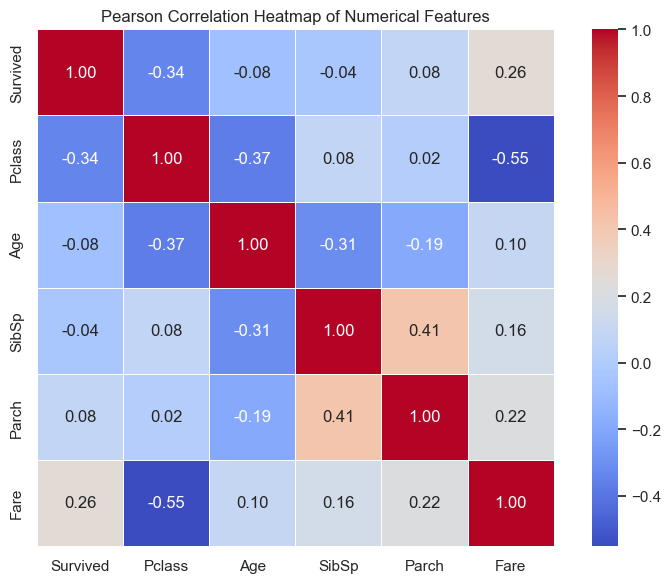

In [5]:
                         
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'PassengerId' in numerical_cols:

    numerical_cols.remove('PassengerId')

corr_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")

print(corr_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)

plt.title('Pearson Correlation Heatmap of Numerical Features')

plt.tight_layout()

plt.show()

In [6]:
                           
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

if 'PassengerId' in numerical_features:

    numerical_features.remove('PassengerId')

if 'Survived' in numerical_features:

    numerical_features.remove('Survived')

print(f"Detected Numerical Features ({len(numerical_features)}): {numerical_features}")

print(f"Detected Categorical Features ({len(categorical_features)}): {categorical_features}")

Detected Numerical Features (5): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Detected Categorical Features (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [7]:
df_clean = df.copy()

emb_mode = df_clean['Embarked'].mode()[0]

df_clean['Embarked'].fillna(emb_mode, inplace=True)

print(f"Imputed missing Embarked with mode: '{emb_mode}'")

df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

title_mapping = {

    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',

    'Lady': 'Mrs', 'Countess': 'Mrs', 'Dona': 'Mrs',

    'Don': 'Rare', 'Sir': 'Rare', 'Jonkheer': 'Rare',

    'Capt': 'Rare', 'Col': 'Rare', 'Major': 'Rare',

    'Dr': 'Rare', 'Rev': 'Rare', 'Don': 'Rare', 'Dem': 'Rare'

}

df_clean['Title'] = df_clean['Title'].replace(title_mapping)

valid_titles = ['Mr', 'Mrs', 'Miss', 'Master', 'Rare']

df_clean['Title'] = df_clean['Title'].apply(lambda x: x if x in valid_titles else 'Rare')

title_medians = df_clean.groupby('Title')['Age'].median()

print("\nMedian age by Title group:")

print(title_medians)

df_clean['Age'] = df_clean.apply(

    lambda r: title_medians[r['Title']] if pd.isnull(r['Age']) else r['Age'],

    axis=1

)

print("\nImputed missing Age values using Title group medians.")

df_clean.drop(columns=['PassengerId', 'Cabin', 'Ticket'], inplace=True)

print(f"Cleaned dataset shape: {df_clean.shape}")

df_clean.head()

Imputed missing Embarked with mode: 'S'

Median age by Title group:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      49.0
Name: Age, dtype: float64

Imputed missing Age values using Title group medians.
Cleaned dataset shape: (891, 10)


In [8]:
                                          
df_A = df_clean.drop(columns=['Name', 'Title'])

df_A_encoded = pd.get_dummies(df_A, columns=['Sex', 'Embarked'], drop_first=True)

X_A_unscaled = df_A_encoded.drop(columns=['Survived'])

y_A = df_A_encoded['Survived']

scaler_A = StandardScaler()

X_A_scaled = pd.DataFrame(scaler_A.fit_transform(X_A_unscaled), columns=X_A_unscaled.columns)

print("Feature Set A Columns:")

print(list(X_A_scaled.columns))

X_A_scaled.head()

Feature Set A Columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [9]:
                                            
df_B = df_clean.copy()

df_B['FamilySize'] = df_B['SibSp'] + df_B['Parch'] + 1

df_B['IsAlone'] = (df_B['FamilySize'] == 1).astype(int)

df_B['AgeGroup'] = pd.cut(

    df_B['Age'],

    bins=[0, 12, 18, 35, 60, 100],

    labels=['Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']

)

df_B['FareGroup'] = pd.qcut(

    df_B['Fare'],

    q=4,

    labels=['Low', 'Medium', 'Mid_High', 'High']

)

df_B.drop(columns=['Name'], inplace=True)

categorical_B = ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup']

df_B_encoded = pd.get_dummies(df_B, columns=categorical_B, drop_first=True)

X_B_unscaled = df_B_encoded.drop(columns=['Survived'])

y_B = df_B_encoded['Survived']

scaler_B = StandardScaler()

X_B_scaled = pd.DataFrame(scaler_B.fit_transform(X_B_unscaled), columns=X_B_unscaled.columns)

print("Feature Set B Columns:")

print(list(X_B_scaled.columns))

print(f"\nFeature Set B Shape: {X_B_scaled.shape}")

X_B_scaled.head()

Feature Set B Columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young_Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareGroup_Medium', 'FareGroup_Mid_High', 'FareGroup_High']

Feature Set B Shape: (891, 21)


In [10]:
                                                
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(

    X_A_unscaled, y_A, test_size=0.2, random_state=42, stratify=y_A

)

X_train_scaled, X_test_scaled, _, _ = train_test_split(

    X_A_scaled, y_A, test_size=0.2, random_state=42, stratify=y_A

)

svm_unscaled = SVC(kernel='rbf', random_state=42)

svm_unscaled.fit(X_train_unscaled, y_train)

train_acc_unscaled = svm_unscaled.score(X_train_unscaled, y_train)

test_acc_unscaled = svm_unscaled.score(X_test_unscaled, y_test)

svm_scaled = SVC(kernel='rbf', random_state=42)

svm_scaled.fit(X_train_scaled, y_train)

train_acc_scaled = svm_scaled.score(X_train_scaled, y_train)

test_acc_scaled = svm_scaled.score(X_test_scaled, y_test)

scaling_comp = pd.DataFrame({

    'Metric': ['Training Accuracy', 'Testing Accuracy'],

    'Without Scaling (Original)': [f"{train_acc_unscaled*100:.2f}%", f"{test_acc_unscaled*100:.2f}%"],

    'With Scaling (Standardized)': [f"{train_acc_scaled*100:.2f}%", f"{test_acc_scaled*100:.2f}%"]

})

print("Comparison of SVM Performance With and Without Scaling:")

print(scaling_comp.to_string(index=False))

Comparison of SVM Performance With and Without Scaling:
           Metric Without Scaling (Original) With Scaling (Standardized)
Training Accuracy                     69.80%                      84.69%
 Testing Accuracy                     62.57%                      81.56%


In [11]:
                                                  
results = []

def run_svm_model(X_train, X_test, y_train, y_test, kernel, feature_set_name, **kwargs):

    clf = SVC(kernel=kernel, random_state=42, **kwargs)

    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)

    y_test_pred = clf.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)

    test_acc = accuracy_score(y_test, y_test_pred)

    print("=" * 65)

    print(f"Kernel: {kernel.upper()} | Feature Set: {feature_set_name}")

    print("=" * 65)

    print(f"Training Accuracy: {train_acc*100:.2f}%")

    print(f"Testing Accuracy:  {test_acc*100:.2f}%")

    print("\nClassification Report:")

    print(classification_report(y_test, y_test_pred, target_names=['Deceased (0)', 'Survived (1)']))

    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,

                xticklabels=['Deceased', 'Survived'], yticklabels=['Deceased', 'Survived'])

    plt.title(f'Confusion Matrix: {kernel.capitalize()} Kernel ({feature_set_name})')

    plt.ylabel('True Class')

    plt.xlabel('Predicted Class')

    plt.tight_layout()

    plt.show()

    results.append({

        'Feature Set': feature_set_name,

        'Kernel': kernel.capitalize(),

        'Training Accuracy': train_acc,

        'Testing Accuracy': test_acc,

        'Train-Test Gap': train_acc - test_acc

    })

    return clf

=== TRAINING ON FEATURE SET A (ORIGINAL CLEANED) ===
Kernel: LINEAR | Feature Set: Feature Set A
Training Accuracy: 78.93%
Testing Accuracy:  77.65%

Classification Report:
              precision    recall  f1-score   support

Deceased (0)       0.80      0.85      0.82       110
Survived (1)       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179

Kernel: POLY | Feature Set: Feature Set A
Training Accuracy: 84.27%
Testing Accuracy:  80.45%

Classification Report:
              precision    recall  f1-score   support

Deceased (0)       0.78      0.95      0.86       110
Survived (1)       0.87      0.58      0.70        69

    accuracy                           0.80       179
   macro avg       0.83      0.76      0.78       179
weighted avg       0.82      0.80      0.79       179

Kernel: RBF | Feature Set: Feature Set A
Training Accur

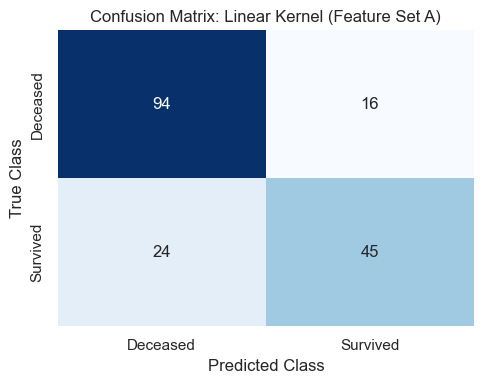

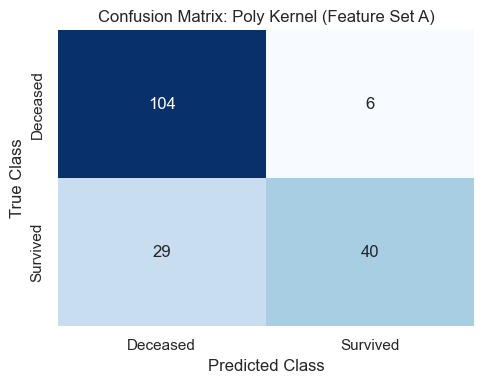

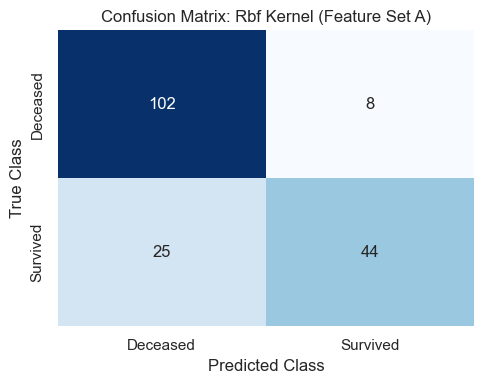

In [12]:
                                   
print("=== TRAINING ON FEATURE SET A (ORIGINAL CLEANED) ===")

clf_linear_A = run_svm_model(X_train_scaled, X_test_scaled, y_train, y_test, kernel='linear', feature_set_name='Feature Set A')

clf_poly_A = run_svm_model(X_train_scaled, X_test_scaled, y_train, y_test, kernel='poly', degree=3, feature_set_name='Feature Set A')

clf_rbf_A = run_svm_model(X_train_scaled, X_test_scaled, y_train, y_test, kernel='rbf', feature_set_name='Feature Set A')

=== TRAINING ON FEATURE SET B (FEATURE ENGINEERED) ===
Kernel: LINEAR | Feature Set: Feature Set B
Training Accuracy: 83.01%
Testing Accuracy:  82.68%

Classification Report:
              precision    recall  f1-score   support

Deceased (0)       0.83      0.90      0.86       110
Survived (1)       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

Kernel: POLY | Feature Set: Feature Set B
Training Accuracy: 85.96%
Testing Accuracy:  81.56%

Classification Report:
              precision    recall  f1-score   support

Deceased (0)       0.82      0.89      0.86       110
Survived (1)       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

Kernel: RBF | Feature Set: Feature Set B
Training Acc

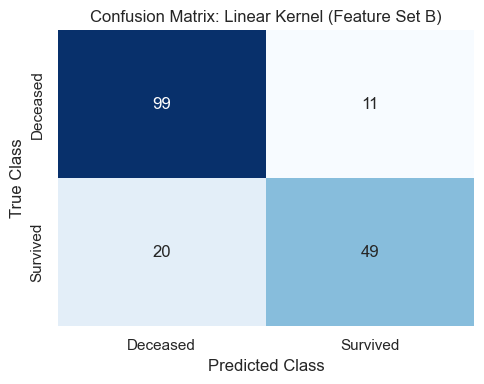

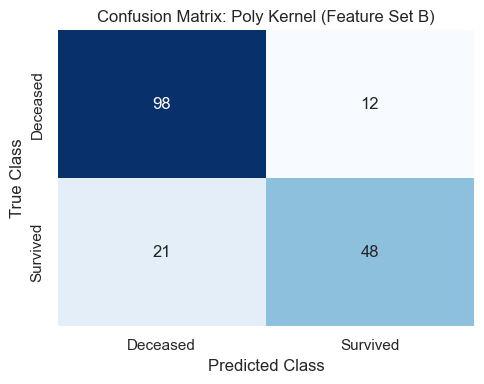

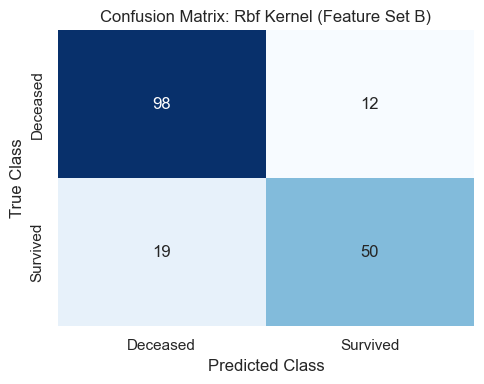

In [13]:
                                            
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(

    X_B_scaled, y_B, test_size=0.2, random_state=42, stratify=y_B

)

print("=== TRAINING ON FEATURE SET B (FEATURE ENGINEERED) ===")

clf_linear_B = run_svm_model(X_train_B, X_test_B, y_train_B, y_test_B, kernel='linear', feature_set_name='Feature Set B')

clf_poly_B = run_svm_model(X_train_B, X_test_B, y_train_B, y_test_B, kernel='poly', degree=3, feature_set_name='Feature Set B')

clf_rbf_B = run_svm_model(X_train_B, X_test_B, y_train_B, y_test_B, kernel='rbf', feature_set_name='Feature Set B')

In [14]:
                                        
results_df = pd.DataFrame(results)

results_df['Train-Test Gap'] = results_df['Train-Test Gap'].apply(lambda x: f"{x*100:.2f}%")

formatted_df = results_df.copy()

formatted_df['Training Accuracy'] = formatted_df['Training Accuracy'].apply(lambda x: f"{x*100:.2f}%")

formatted_df['Testing Accuracy'] = formatted_df['Testing Accuracy'].apply(lambda x: f"{x*100:.2f}%")

print("Comparison Summary Table:")

print(formatted_df.to_string(index=False))

Comparison Summary Table:
  Feature Set Kernel Training Accuracy Testing Accuracy Train-Test Gap
Feature Set A Linear            78.93%           77.65%          1.28%
Feature Set A   Poly            84.27%           80.45%          3.82%
Feature Set A    Rbf            84.69%           81.56%          3.13%
Feature Set B Linear            83.01%           82.68%          0.32%
Feature Set B   Poly            85.96%           81.56%          4.39%
Feature Set B    Rbf            84.69%           82.68%          2.01%
